<a href="https://colab.research.google.com/github/OlaStrzelczyk/Non-relational_database_project/blob/main/Projekt_AOKO_zaliczenie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automatyczna klasyfikacja zmian nowotworowych na obrazach ultrasonograficznych do klas: normal, benign, malignant**

# **1. Import bibliotek**

In [6]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# **2. Wczytanie danych**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
dataset_path = "/content/drive/MyDrive/breastCancer"

# **3. Analiza datasetu**

In [9]:
os.listdir(dataset_path)

['malignant', 'normal', 'benign']

In [10]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
for category in os.listdir(dataset_path):
    path = os.path.join(dataset_path, category)
    print(category, len(os.listdir(path)))

malignant 210
normal 133
benign 437


# **4. Preprocessing**

In [12]:
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 780 files belonging to 3 classes.
Using 624 files for training.
Found 780 files belonging to 3 classes.
Using 156 files for validation.


In [13]:
class_names = train_ds.class_names
print(class_names)

['benign', 'malignant', 'normal']


# **5. Augmentacja danych**

In [14]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# **6. Budowa modelu**

In [15]:
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **7. Trening baseline**

In [16]:
inputs = keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(3, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# **8. Kopilacja**

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy'
    ]
)

# **9. CALLBACKI**

In [18]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2
    ),

    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor='val_accuracy',
        save_best_only=True
    )

]

# **10. Obliczanie wag klas**

In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = np.concatenate([
    y.numpy() for x, y in train_ds
])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5909090909090909), 1: np.float64(1.2530120481927711), 2: np.float64(1.9622641509433962)}


# **11. TRENING - ponowny**

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.4744 - loss: 1.0305 - val_accuracy: 0.5705 - val_loss: 0.8969 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 327ms/step - accuracy: 0.5689 - loss: 0.8866 - val_accuracy: 0.6218 - val_loss: 0.7950 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 475ms/step - accuracy: 0.6314 - loss: 0.8167 - val_accuracy: 0.6410 - val_loss: 0.7702 - learning_rate: 0.0010
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 292ms/step - accuracy: 0.6410 - loss: 0.7861 - val_accuracy: 0.6346 - val_loss: 0.7120 - learning_rate: 0.0010
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 292ms/step - accuracy: 0.6667 - loss: 0.7279 - val_accuracy: 0.6410 - val_loss: 0.7391 - learning_rate: 0.0010
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 407ms/step - accuracy: 0.6635 - loss: 0.7113 - val_accuracy: 0.6923 - val_loss: 0.6864 - learning_rate: 0.0010
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 289ms/step - accuracy: 0.6731 - loss: 0.6943 - v

# **12. Matrix**

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 631ms/step


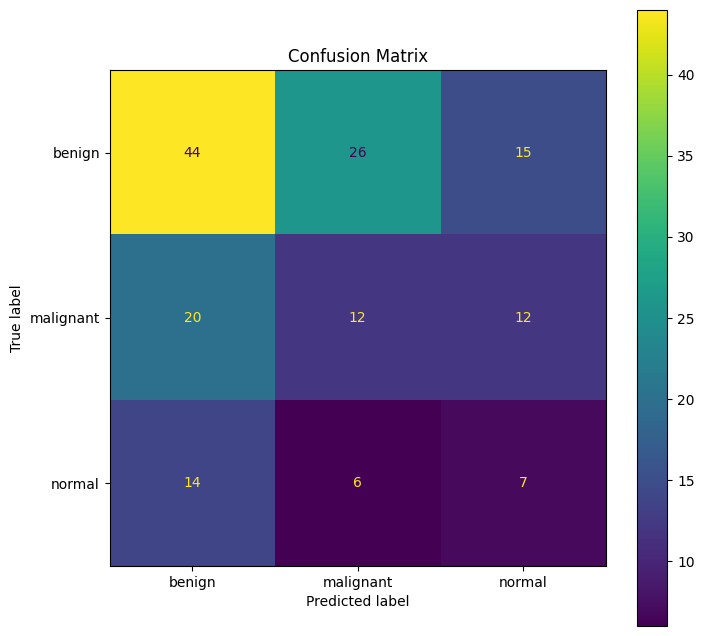

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_true = np.concatenate([
    y for x, y in val_ds
], axis=0)

y_pred = np.argmax(
    model.predict(val_ds),
    axis=1
)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

# **13. Raport klasyfikacji**

In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      benign       0.56      0.52      0.54        85
   malignant       0.27      0.27      0.27        44
      normal       0.21      0.26      0.23        27

    accuracy                           0.40       156
   macro avg       0.35      0.35      0.35       156
weighted avg       0.42      0.40      0.41       156



# **14. WYKRESY**

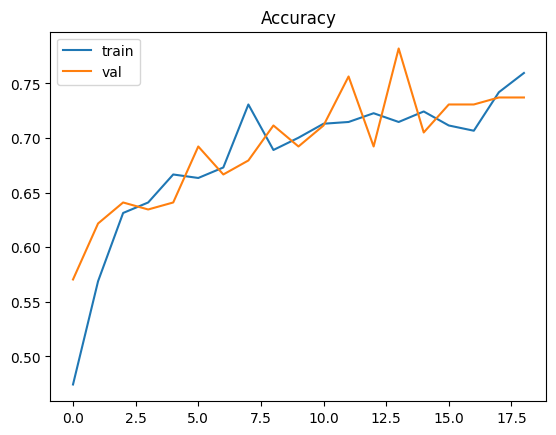

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['train', 'val'])

plt.title("Accuracy")

plt.show()

# **15. fine-tuning modelu — in. odmrażanie części warstw**

In [24]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# **16. Rekompilacja**

In [25]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# **Podejście nr 2**

# **17. fine-tuning - inny**

In [32]:
base_model.trainable = True

for layer in base_model.layers[:-15]:
    layer.trainable = False

# **18. kompilacja modelu**

In [33]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# **19. Wagi klas**

In [34]:
class_weights = {
    0: 0.6,   # benign
    1: 2.0,   # malignant
    2: 2.0    # normal
}

# **20. inna augumentacja**

In [35]:
data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.15),

    layers.RandomZoom(0.15),

    layers.RandomContrast(0.2),

    layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    ),
])

# **21. znowu trening**

In [36]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 535ms/step - accuracy: 0.7115 - loss: 0.8673 - val_accuracy: 0.7756 - val_loss: 0.6162 - learning_rate: 1.0000e-05
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 297ms/step - accuracy: 0.7147 - loss: 0.8871 - val_accuracy: 0.7628 - val_loss: 0.6245 - learning_rate: 1.0000e-05
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 390ms/step - accuracy: 0.7292 - loss: 0.8628 - val_accuracy: 0.7500 - val_loss: 0.6283 - learning_rate: 2.0000e-06


# **22. załadowanie zapisanego modelu**

In [37]:
model = keras.models.load_model("best_model.keras")

# **23. ewaluacji modelu klasyfikacyjnego**

In [38]:
import numpy as np
from sklearn.metrics import classification_report

y_true = np.concatenate([
    y for x, y in val_ds
], axis=0)

y_pred_probs = model.predict(val_ds)

y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
              precision    recall  f1-score   support

      benign       0.62      0.56      0.59        85
   malignant       0.27      0.27      0.27        44
      normal       0.12      0.15      0.13        27

    accuracy                           0.41       156
   macro avg       0.34      0.33      0.33       156
weighted avg       0.43      0.41      0.42       156



# **24. macierz pomyłek**

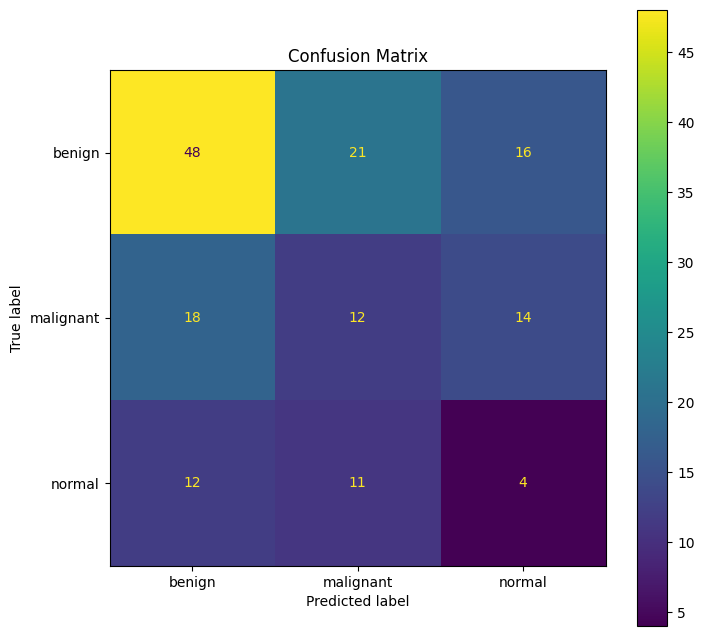

In [39]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

# **25. kompilacja modelu z Focal Loss**

In [ ]:
import tensorflow as tf

loss_fn = tf.keras.losses.CategoricalFocalCrossentropy()

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

# **26. fine-tuning modelu z ważeniem klas**

In [40]:
import tensorflow as tf

class_weights = {
    0: 0.5,
    1: 3.0,
    2: 4.0
}

base_model.trainable = True

for layer in base_model.layers[:-15]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        'accuracy'
    ]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 823ms/step - accuracy: 0.7548 - loss: 1.1219 - val_accuracy: 0.7692 - val_loss: 0.6081 - learning_rate: 1.0000e-05
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 331ms/step - accuracy: 0.7340 - loss: 1.0821 - val_accuracy: 0.7500 - val_loss: 0.6122 - learning_rate: 1.0000e-05
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 429ms/step - accuracy: 0.7260 - loss: 1.0756 - val_accuracy: 0.7436 - val_loss: 0.6130 - learning_rate: 2.0000e-06


# **27. zmniejszenie wagi benign oraz zwiększenie normal i malignant**

In [41]:
class_weights = {
    0: 0.5,
    1: 3.0,
    2: 4.0
}

# **28. ponowny trening**

In [42]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 289ms/step - accuracy: 0.7356 - loss: 1.1052 - val_accuracy: 0.7692 - val_loss: 0.6089 - learning_rate: 2.0000e-06
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 383ms/step - accuracy: 0.7308 - loss: 1.0802 - val_accuracy: 0.7692 - val_loss: 0.6096 - learning_rate: 2.0000e-06
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.7436 - loss: 1.0883 - val_accuracy: 0.7692 - val_loss: 0.6098 - learning_rate: 4.0000e-07


# **29. ewaluacji modelu klasyfikacyjnego + wizualizacji wyników**

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 797ms/step
              precision    recall  f1-score   support

      benign       0.54      0.48      0.51        85
   malignant       0.33      0.34      0.33        44
      normal       0.15      0.19      0.16        27

    accuracy                           0.39       156
   macro avg       0.34      0.34      0.34       156
weighted avg       0.41      0.39      0.40       156



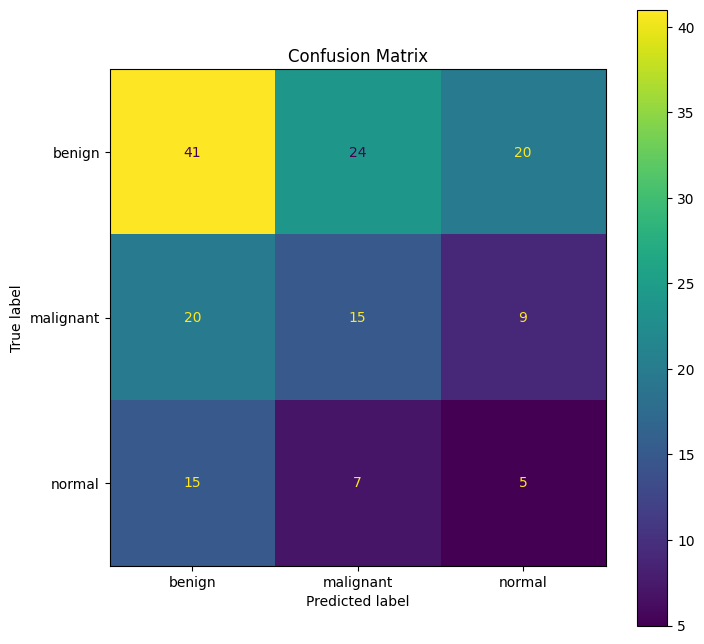

In [43]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np
import matplotlib.pyplot as plt

y_true = np.concatenate([
    y for x, y in val_ds
], axis=0)

y_pred_probs = model.predict(val_ds)

y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

In [44]:
model = keras.models.load_model("best_model.keras")

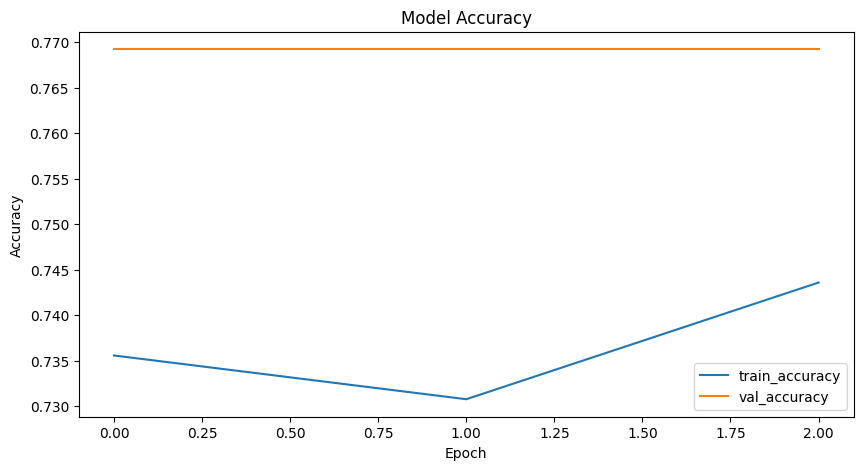

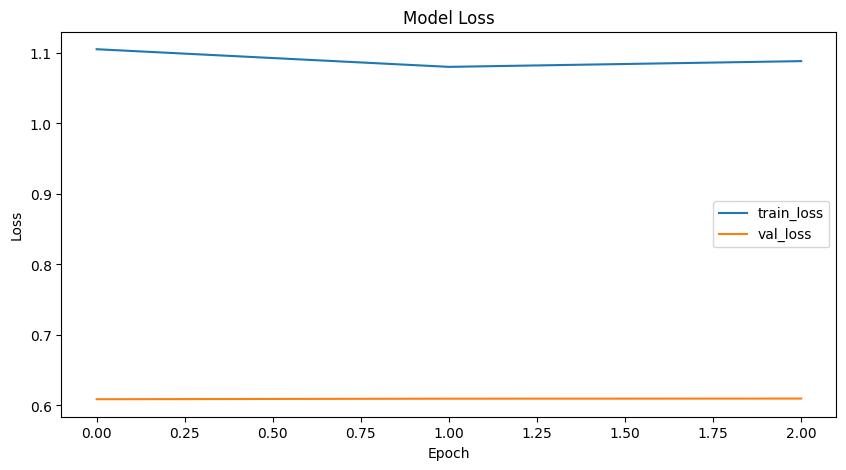

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 742ms/step

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

      benign       0.58      0.53      0.55        85
   malignant       0.32      0.32      0.32        44
      normal       0.29      0.37      0.33        27

    accuracy                           0.44       156
   macro avg       0.40      0.41      0.40       156
weighted avg       0.45      0.44      0.45       156



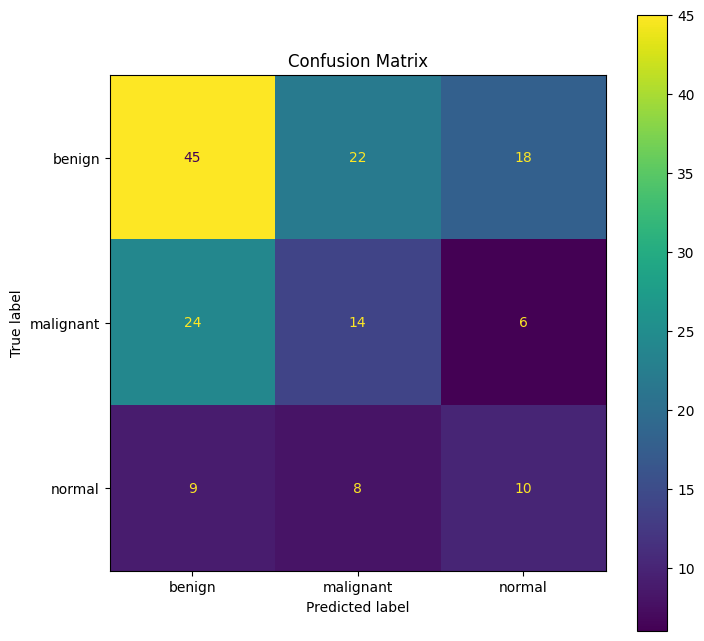

In [45]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

y_true = np.concatenate([
    y for x, y in val_ds
], axis=0)

y_pred_probs = model.predict(val_ds)

y_pred = np.argmax(y_pred_probs, axis=1)

print("\nCLASSIFICATION REPORT:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

Model został zapisany.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


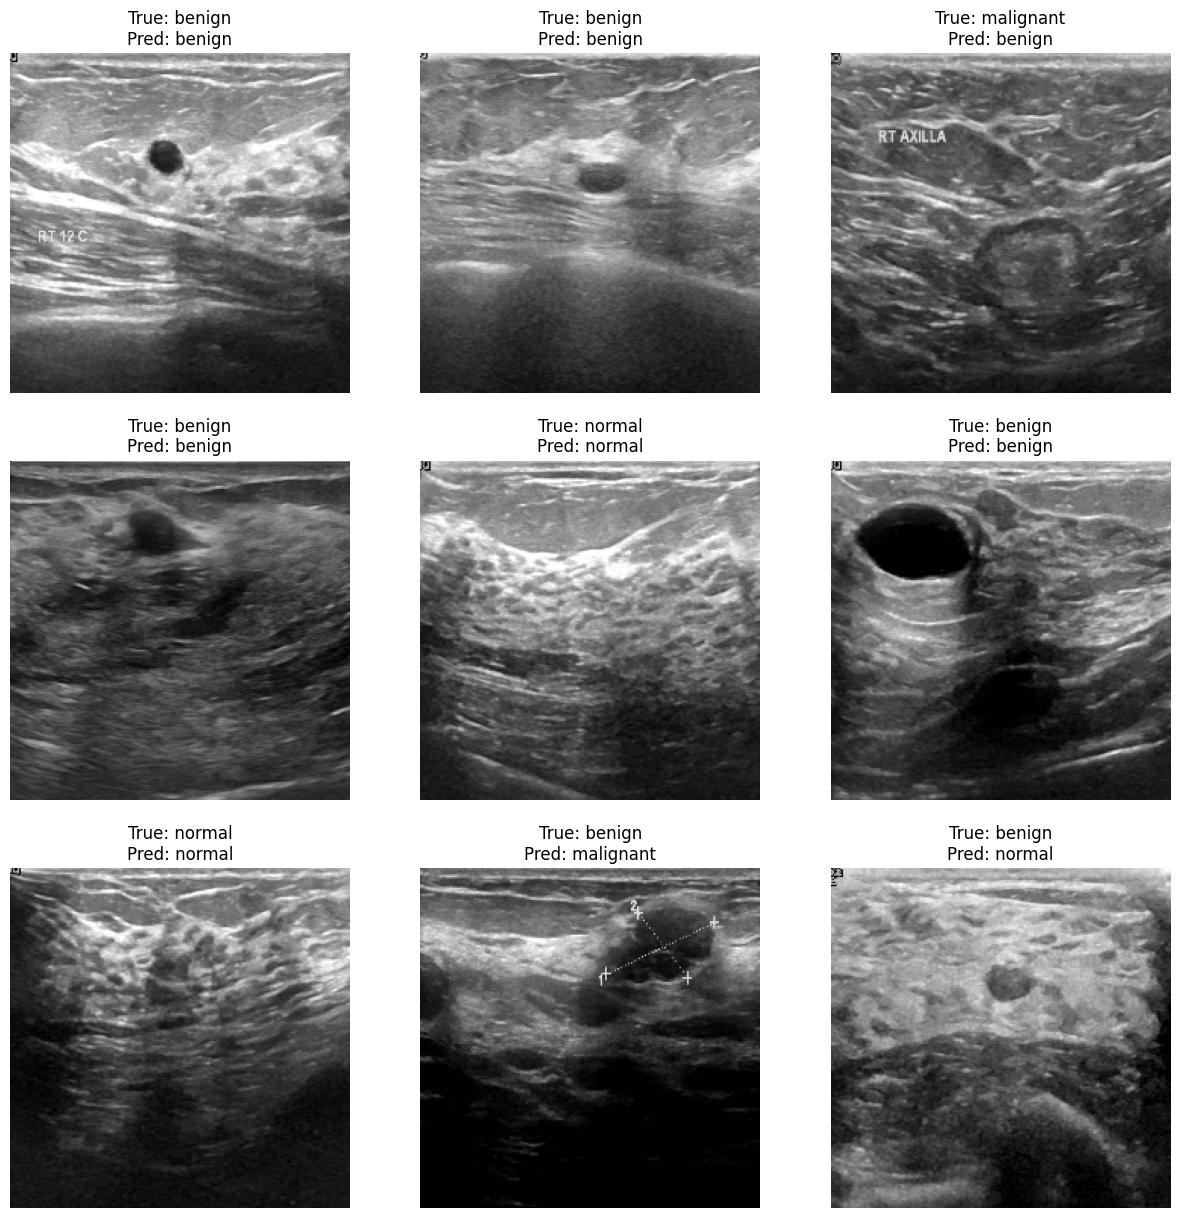

In [46]:
import matplotlib.pyplot as plt
import numpy as np

model.save("breast_cancer_model.keras")

print("Model został zapisany.")

plt.figure(figsize=(15,15))

for images, labels in val_ds.take(1):

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        pred_label = class_names[predicted_labels[i]]

        plt.title(
            f"True: {true_label}\nPred: {pred_label}"
        )

        plt.axis("off")

plt.show()

In [49]:
model.save("breast_cancer_model.keras")

print("Model został zapisany.")

Model został zapisany.


In [50]:
model.save("/content/drive/MyDrive/breast_cancer_model.keras")

print("Model zapisany na Google Drive.")

Model zapisany na Google Drive.


In [51]:
model = keras.models.load_model(
    "/content/drive/MyDrive/breast_cancer_model.keras"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


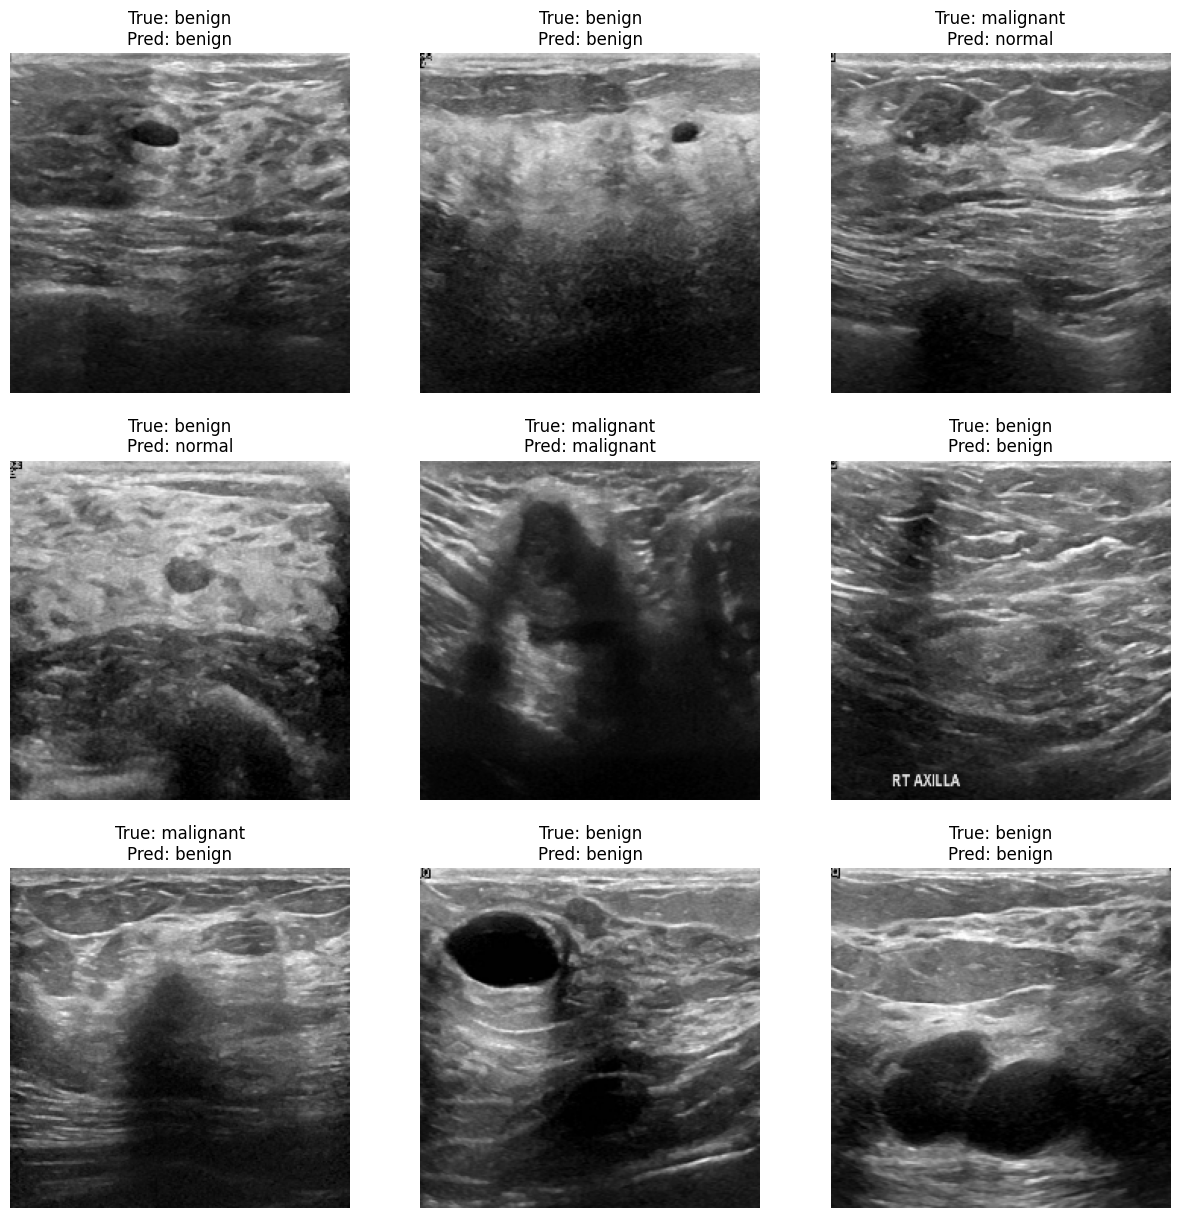

In [52]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,15))

for images, labels in val_ds.take(1):

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        pred_label = class_names[predicted_labels[i]]

        plt.title(
            f"True: {true_label}\nPred: {pred_label}"
        )

        plt.axis("off")

plt.show()